## Student Performance Indicator



#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

### Import the CSV Dataset as a Pandas DataFrame

In [3]:
df = pd.read_csv('data/StudPerf.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Observation:
### There are no missing values in the Dataset.

## 3.2 Check for duplicate records:

In [7]:
df.duplicated().sum()

np.int64(0)

## Observation:
### There are duplicate values in the Dataset.

## 3.3 Check Data type:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## 3.4 Checking the number of unique values in each column:

In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

## 3.5 Check the Statistics of the Dataset:

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

## 3.6 Exploring the various categories of data in the Dataset:

In [13]:
print("Categories in 'gender' feature:  ", end= " ")
print(df['gender'].unique())

print("Categories in race/ethnicity feature:    ", end= " ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' feature: ", end= " ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:  ", end= " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' feature: ", end= " ")
print(df['test preparation course'].unique())

Categories in 'gender' feature:   ['female' 'male']
Categories in race/ethnicity feature:     ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' feature:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:   ['standard' 'free/reduced']
Categories in 'test preparation course' feature:  ['none' 'completed']


In [17]:
#Define Numerical and Categorical Features:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']

#Print the categories:
print("We have {} numerical features: {}".format(len(num_features), num_features))
print("\nWe have {} categorical features: {}".format(len(cat_features), cat_features))

We have 3 numerical features: ['math score', 'reading score', 'writing score']

We have 5 categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## 3.8 Adding new features 'Total Score' and 'Average':

In [18]:
df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']
df['Average'] = df['Total Score']/3

In [19]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
reading_full = df[df['reading score'] == 100]['Average'].count()
writing_full = df[df['writing score'] == 100]['Average'].count()
math_full = df[df['math score'] == 100]['Average'].count()

print(f"Number of students with full score in Maths: {math_full}")
print(f"Number of students with full score in Reading: {reading_full}")
print(f"Number of students with full score in Writing: {writing_full}")

Number of students with full score in Maths: 7
Number of students with full score in Reading: 17
Number of students with full score in Writing: 14


In [23]:
reading_less_20 = df[df['reading score'] < 20]['Average'].count()
writing_less_20 = df[df['writing score'] < 20]['Average'].count()
math_less_20 = df[df['math score'] < 20]['Average'].count()

print(f"Number of students with score less than 20 in reading: {reading_less_20}")
print(f"Number of students with score less than 20 in writing: {writing_less_20}")
print(f"Number of students with score less than 20 in math: {math_less_20}")

Number of students with score less than 20 in reading: 1
Number of students with score less than 20 in writing: 3
Number of students with score less than 20 in math: 4


### Obervations:

- From the above we can see that the students have performed the best in Reading and the worst in Maths.

## 4. More Exploring Data (Visualization):
### 4.1 Visualize the Average score distribution to make a conclusion. 

### 4.1.1 Histogram & KDE:

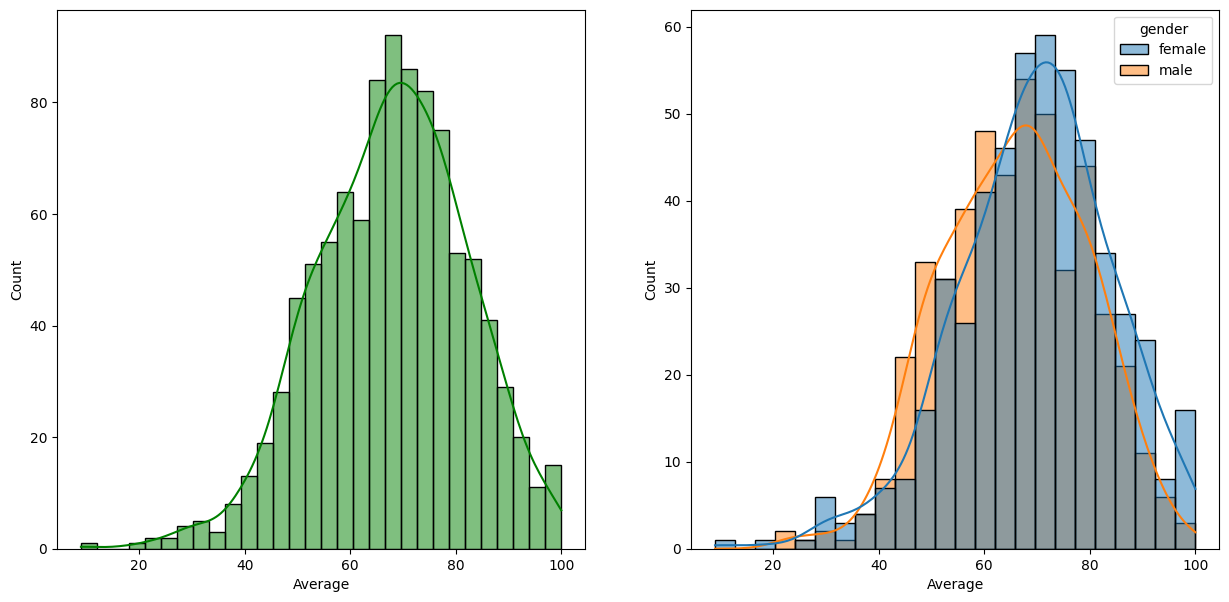

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

plt.subplot(121)
sns.histplot(data= df, x= 'Average', bins= 30, kde= True, color= 'g')

plt.subplot(122)
sns.histplot(data= df, x= 'Average', kde= True, hue= 'gender')

plt.show()

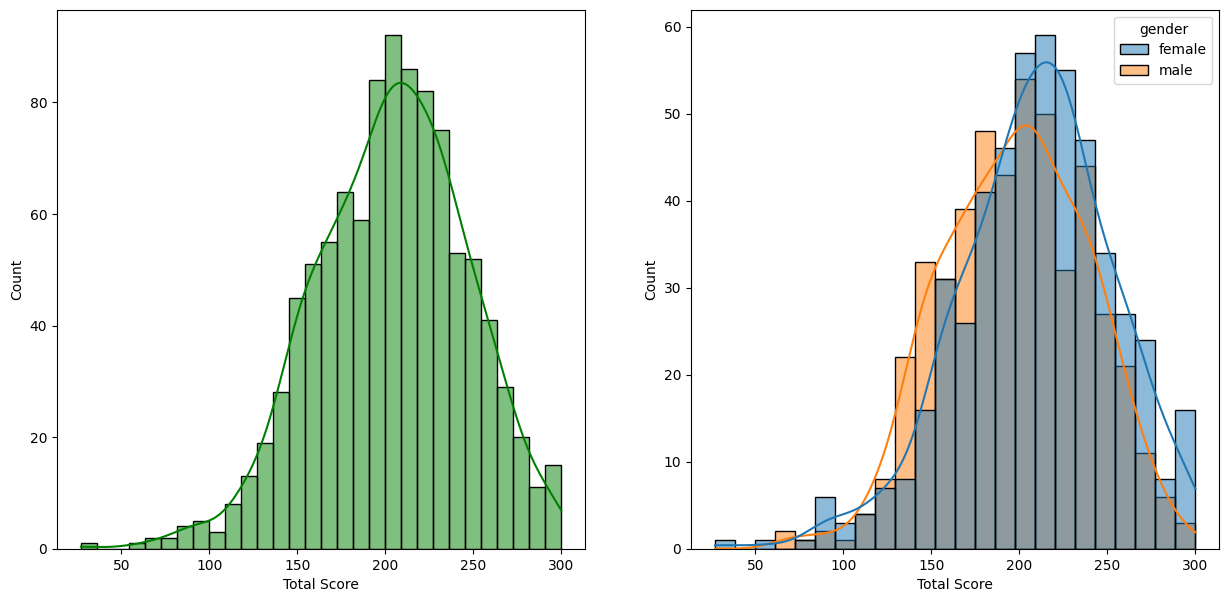

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

plt.subplot(121)
sns.histplot(data= df, x= 'Total Score', bins= 30, kde= True, color= 'g')

plt.subplot(122)
sns.histplot(data= df, x= 'Total Score', kde= True, hue= 'gender')

plt.show()

### Observation:
- Females tend to perform well than males. 

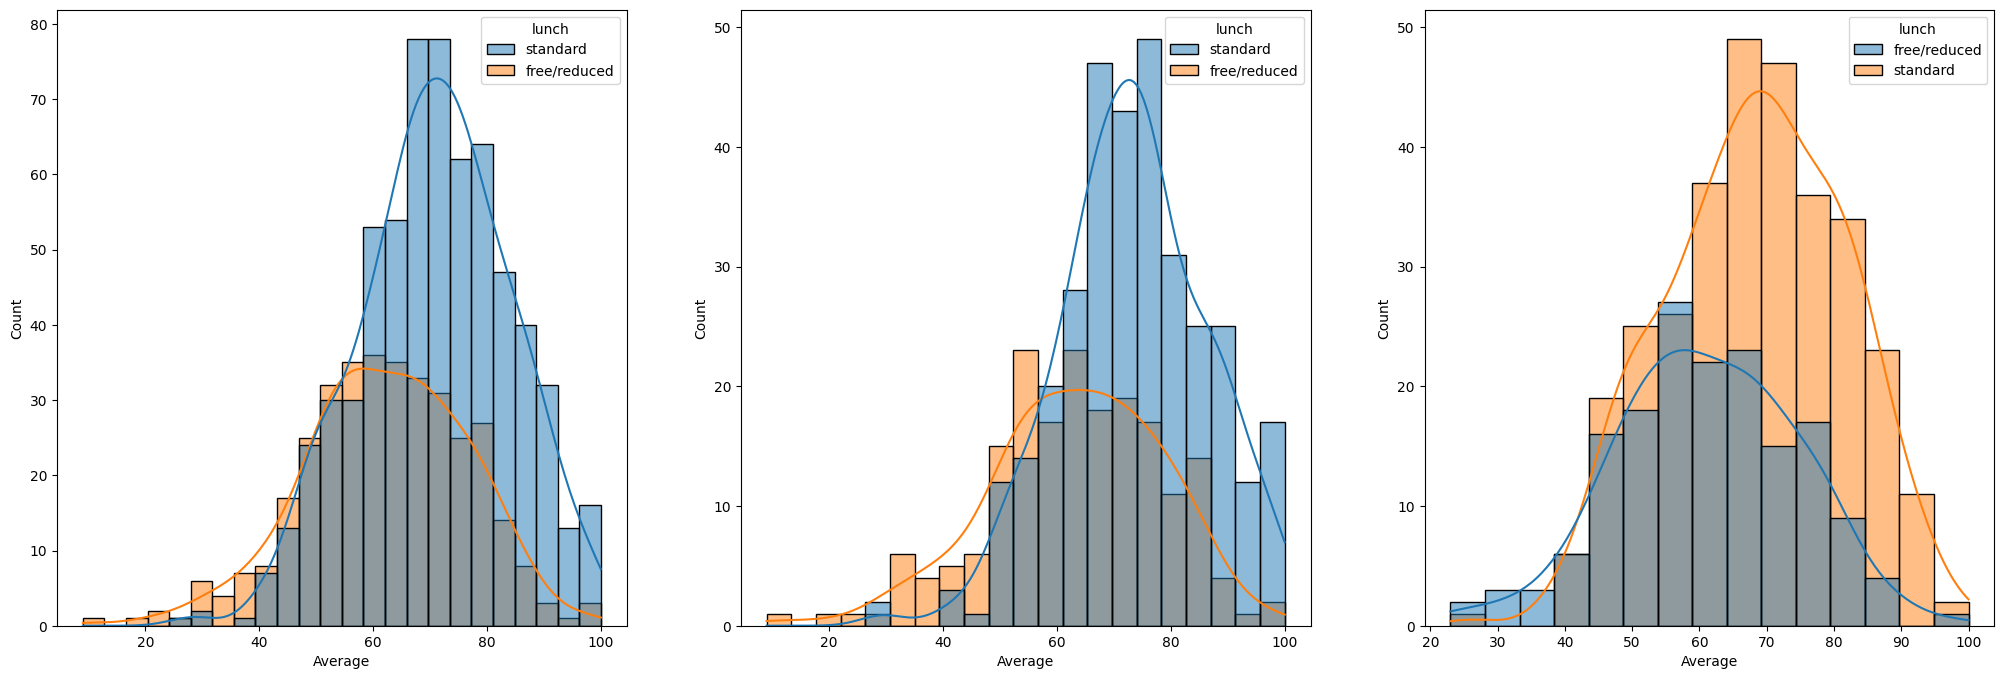

In [37]:
plt.subplots(1,3, figsize= (25,8))

plt.subplot(131)
sns.histplot(data= df, x= 'Average', kde= True, hue= 'lunch')

plt.subplot(132)
sns.histplot(data= df[df.gender == 'female'], x= 'Average', kde= True, hue= 'lunch')

plt.subplot(133)
sns.histplot(data= df[df.gender == 'male'], x= 'Average', kde= True, hue= 'lunch')

plt.show()